In [2]:
# Célula 1: Importación de librerías y Configuración
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from src import Extractor
# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
TABLE_NAME="works4cdp_assay"
SAMPLE_ID=24 #Concentrado final de courier cobre

db_config = {
    'user': 'myuser', 
    'password': 'mypassword', 
    'host': 'localhost', 
    'port': '5432', 
    'dbname': 'mydb'
}

datos = Extractor(table_name=TABLE_NAME, **db_config)

df_intensidad = datos.get_intensity(SAMPLE_ID)

df_intensidad.head()

,date,time,instance,n1fe,n2cu,n3zn,n4mo,n5ech5,n6sc,n7ech7
0,2025-12-03,11:01:00,1764777025,33558,38556,322,1690,None,1783,None
1,2025-12-01,11:04:20,1764604983,30953,34624,212,2667,None,1778,None
2,2025-12-01,11:01:46,1764604638,31900,35195,218,2587,None,1756,None
3,2025-11-28,12:29:52,1764349910,37782,39341,279,1812,None,1646,None
4,2025-11-26,11:11:58,1764173370,37364,42379,343,2409,None,1728,None


Datos originales: 468
Datos limpios:    444 (Ruido eliminado: 24)


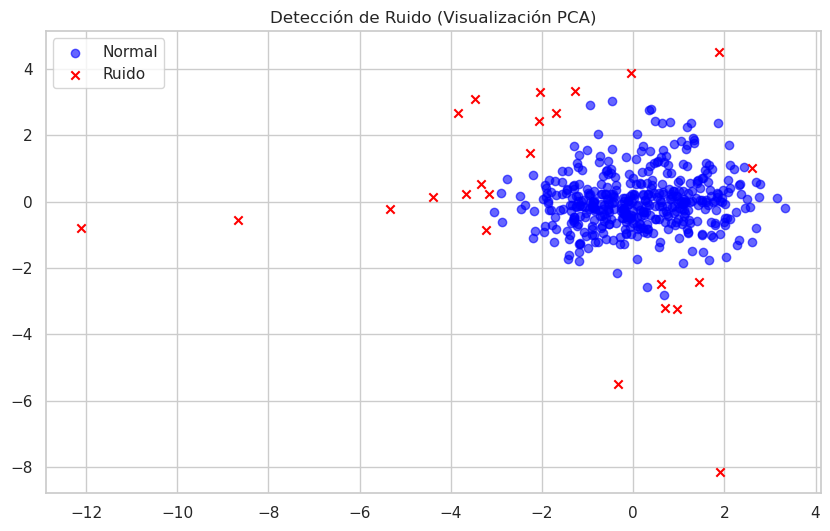

In [6]:
# Célula 2: Preprocesamiento y Detección de Ruido (Outliers)
# -----------------------------------------------------------------------------
# 1. Selección de características
features = ['n1fe', 'n2cu', 'n3zn', 'n4mo', 'n6sc']
X_raw = df_intensidad[features].dropna()

# 2. Normalización
# Usamos StandardScaler para que todas las variables tengan media 0 y desviación 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 3. Detección de Ruido con Isolation Forest
# Este algoritmo aísla observaciones anómalas
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Asumimos 5% de ruido aprox.
outlier_labels = iso_forest.fit_predict(X_scaled)

# Crear DataFrame limpio (donde label == 1) y de ruido (donde label == -1)
X_clean = X_scaled[outlier_labels == 1]
X_noise = X_scaled[outlier_labels == -1]
df_clean = df_intensidad.loc[X_raw.index[outlier_labels == 1]].copy()

print(f"Datos originales: {len(X_scaled)}")
print(f"Datos limpios:    {len(X_clean)} (Ruido eliminado: {len(X_noise)})")

# Visualización del Ruido usando PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[outlier_labels == 1, 0], X_pca[outlier_labels == 1, 1], c='blue', label='Normal', alpha=0.6)
plt.scatter(X_pca[outlier_labels == -1, 0], X_pca[outlier_labels == -1, 1], c='red', label='Ruido', marker='x')
plt.title('Detección de Ruido (Visualización PCA)')
plt.legend()
plt.show()

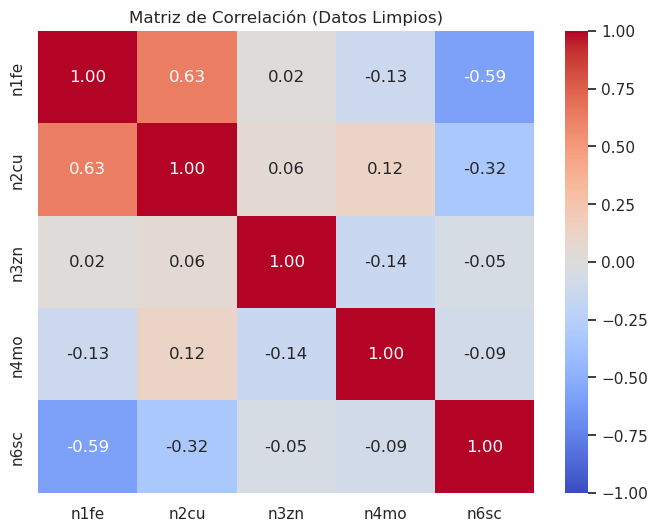

In [7]:
# Célula 3: Re-análisis de Correlación (Sin Ruido)
# -----------------------------------------------------------------------------
# Al quitar el ruido, las correlaciones pueden volverse más claras y fuertes
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación (Datos Limpios)")
plt.show()

In [8]:
# Célula 4: Comparación de Modelos de Agrupamiento
# -----------------------------------------------------------------------------
# Probaremos varios modelos y rangos de clusters
resultados = []
K_range = range(2, 7)

# 1. K-Means
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_clean)
    resultados.append({
        'Modelo': 'K-Means',
        'K': k,
        'Silhouette': silhouette_score(X_clean, labels),
        'Davies-Bouldin': davies_bouldin_score(X_clean, labels), # Menor es mejor
        'Calinski-Harabasz': calinski_harabasz_score(X_clean, labels) # Mayor es mejor
    })

# 2. Hierarchical (Agglomerative)
for k in K_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_clean)
    resultados.append({
        'Modelo': 'Jerárquico',
        'K': k,
        'Silhouette': silhouette_score(X_clean, labels),
        'Davies-Bouldin': davies_bouldin_score(X_clean, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_clean, labels)
    })

# 3. Gaussian Mixture Models (GMM) - Flexible para formas elípticas
for k in K_range:
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(X_clean)
    resultados.append({
        'Modelo': 'GMM',
        'K': k,
        'Silhouette': silhouette_score(X_clean, labels),
        'Davies-Bouldin': davies_bouldin_score(X_clean, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_clean, labels)
    })

# Crear DataFrame de resultados y ordenar por Silhouette
df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values(by='Silhouette', ascending=False).style.background_gradient(cmap='viridis'))

# Selección automática del mejor modelo (basado en Silhouette)
mejor_modelo = df_resultados.loc[df_resultados['Silhouette'].idxmax()]
print(f"\n🏆 MEJOR MODELO SUGERIDO: {mejor_modelo['Modelo']} con K={mejor_modelo['K']}")

,Modelo,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,2,0.300310,1.337007,208.310199
1,K-Means,3,0.299817,1.161978,176.430604
5,Jerárquico,2,0.294167,1.361414,187.497064
10,GMM,2,0.278720,1.463715,173.710210
3,K-Means,5,0.247007,1.262446,149.251893
2,K-Means,4,0.243489,1.352778,164.689550
4,K-Means,6,0.235073,1.308991,138.672504
8,Jerárquico,5,0.221266,1.373378,126.918168
7,Jerárquico,4,0.218699,1.477422,141.572147
6,Jerárquico,3,0.209789,1.631993,143.695472



🏆 MEJOR MODELO SUGERIDO: K-Means con K=2


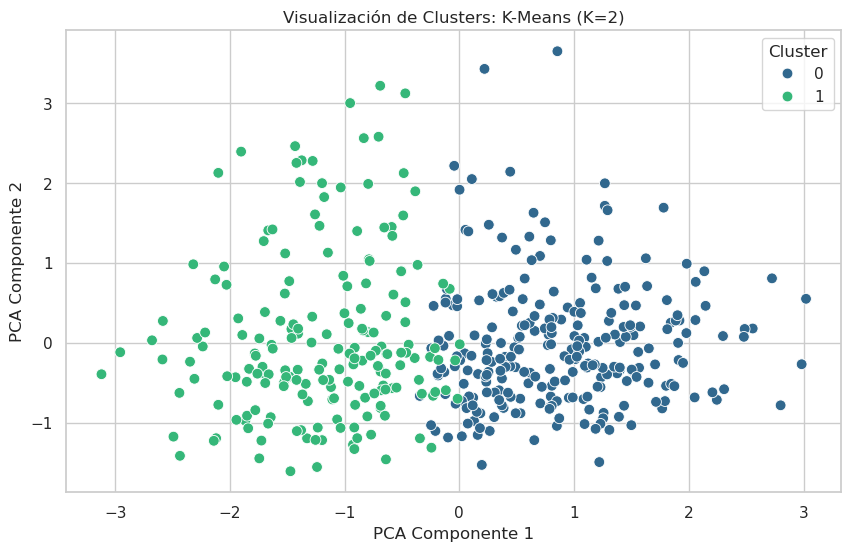


Perfil Promedio por Cluster (Valores Reales):


,n1fe,n2cu,n3zn,n4mo,n6sc
Cluster_Final,,,,,
0,37040.031250,38708.746094,195.386719,2519.777344,1644.582031
1,42294.265957,42005.718085,207.617021,2717.893617,1341.952128


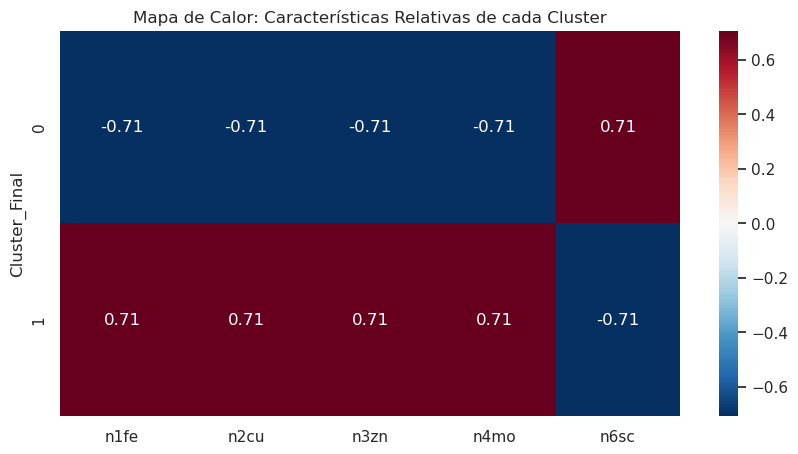

In [9]:
# Célula 5: Visualización y Perfilamiento del Mejor Resultado
# -----------------------------------------------------------------------------
best_k = int(mejor_modelo['K'])
best_algo = mejor_modelo['Modelo']

# Re-entrenar con el ganador
if best_algo == 'K-Means':
    final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_final = final_model.fit_predict(X_clean)
elif best_algo == 'Jerárquico':
    final_model = AgglomerativeClustering(n_clusters=best_k)
    labels_final = final_model.fit_predict(X_clean)
else: # GMM
    final_model = GaussianMixture(n_components=best_k, random_state=42)
    labels_final = final_model.fit_predict(X_clean)

# Añadir etiquetas al DF limpio
df_clean['Cluster_Final'] = labels_final

# Visualización PCA
pca_clean = PCA(n_components=2)
X_pca_clean = pca_clean.fit_transform(X_clean)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_clean[:, 0], y=X_pca_clean[:, 1], hue=labels_final, palette='viridis', s=60)
plt.title(f'Visualización de Clusters: {best_algo} (K={best_k})')
plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.legend(title='Cluster')
plt.show()

# Perfil de los Clusters (Promedios)
print("\nPerfil Promedio por Cluster (Valores Reales):")
perfil = df_clean.groupby('Cluster_Final')[features].mean()
display(perfil)

# Visualización del perfil en Heatmap
plt.figure(figsize=(10, 5))
# Normalizamos el perfil para el heatmap para ver diferencias relativas
sns.heatmap((perfil - perfil.mean()) / perfil.std(), annot=True, cmap='RdBu_r', center=0)
plt.title('Mapa de Calor: Características Relativas de cada Cluster')
plt.show()